# The Distress Puzzle — a quantitative teardown 🔬
### CHS-style distress score · tercile sort · two-sample *t* · label-shuffle placebo · firm-level slope · four-window sign-flip · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distress_puzzle_on_the_tape%3F: Mixed](https://img.shields.io/badge/Distress_puzzle_on_the_tape%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a Campbell-Hilscher-Szilagyi-style distress score, sort the cross-section, and test whether the most-distressed firms earn the lowest returns (the puzzle) — or, here, the highest.

> ⚠️ **Not investment advice.** Real data: yfinance daily prices + a fundamentals snapshot, 39 survivors (as-of 2026-06-26, panel fp `0835f4217788`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from distress_risk_anomaly import data, strategy as st

SPLIT, END = "2024-06-28", "2026-06-25"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    fn = data.fetch_fundamentals(fetch=False)
    if px.empty or not fn:
        return pd.DataFrame()
    return st.build_panel(px, fn, split_date=SPLIT, end_date=END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real distress panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} names, scored {SPLIT} -> {END})")


real distress panel present: True (39 names, scored 2024-06-28 -> 2026-06-25)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Safe − distressed spread **-48.6%** (two-sample *t* **-2.64**, placebo *p* 0.033) — the *wrong* sign; firm slope-*t* **+1.99** (positive = anti-puzzle); sign flips across windows. |
| **Tradability** | `MIRAGE` | Survivor basket, annual rebalance, distressed short = costly borrow. Gross -48.6% → net -50.8% (5 bps/leg + 100 bps borrow). |
| **Distress puzzle on the tape?** | `MIXED` | Present (slope-*t* −2.02 / −1.46) in 2021-23 & 2022-24; inverted in 2023-25 & 2024-26. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this survivor basket over this window the puzzle is absent-to-inverted and sign-unstable.

## 1 · The claim, steelmanned

Let $D_i$ be firm $i$'s CHS-style distress score and $r_i$ its forward return.

- **H₁ (the puzzle / long-short).** $\mathbb{E}[r \mid \text{safe}] - \mathbb{E}[r \mid \text{distressed}] > 0$ at *t* ≥ 2 (safe beats distressed).
- **H₂ (firm-level).** $\text{slope of } r \text{ on } D < 0$ (more distress, less return).
- **H₃ (robustness).** The sign of H₁/H₂ is stable across scoring windows.
- **H₄ (net).** H₁ survives costs and the distressed-leg borrow.

We find **H₁ rejected** (wrong sign on the headline window), **H₂ rejected** (slope is *positive*), **H₃ rejected** (sign flips), and **H₄ moot** (the trade is the wrong sign before costs).

## 2 · So what? — what rides on each answer

The content is the **why**. The puzzle is well documented on full-universe, survivorship-free data driven by firms that *fail*. Two forces kill it here: (a) **survivorship** — the basket already dropped every bankruptcy, removing the extreme left tail that makes distressed stocks lose on average; and (b) a **high-beta melt-up** (2023-26) that rewarded the levered, volatile names the score flags as distressed. That maps to [123 Altman-Z](../../123-altman-z/)'s weak distress reading on the same kind of survivor panel.

## 3 · How we'd know — the protocol

- **Score.** $D = z(\text{leverage}) - z(\text{ROA}) + z(\text{equity vol})$, each z-scored across the basket (higher = more distressed). The three observable CHS legs.
- **Sort.** Tercile tails (≈12 names each): safe (lowest $D$) vs distressed (highest).
- **Inference.** Two-sample (Welch) *t* on the safe − distressed forward returns; a **label-shuffle placebo** null (2000 perms).
- **Firm-level.** OLS of forward return on $D$ — the *sign* of the slope is the puzzle.
- **Robustness.** Re-sort over four scoring windows; read the sign.
- **Frictions.** Round-trip cost per leg + an annual borrow on the distressed short.
- **Positive control.** A deterministic synthetic world with a planted puzzle (`distress_alpha < 0`) and a null — averaged over 25 seeds (house rule).

Timing: distress is scored from trailing data (the realised-vol window ending at the split close) + the last statements, so the signal is fully public at that close; we enter at that close and hold over the forward window. No future data enters the score (no look-ahead). The same-close fill is a documented convention — on a ~2-year hold a one-bar-later entry moves the headline spread ~1pt and changes no stamp.

## 4 · The teardown

### 4a · The sort — H₁

Safe vs distressed forward returns, with the two-sample *t* and the placebo null.

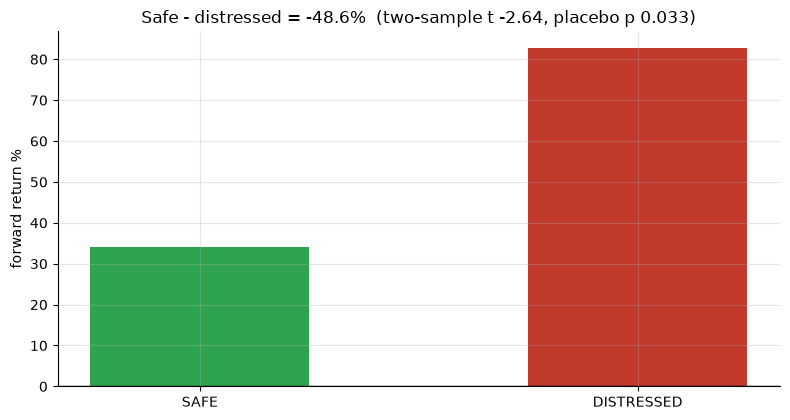

Safe +34.1% | Distressed +82.7% | spread -48.6% | t -2.64 | placebo p 0.033


In [2]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3); ls = st.long_short_tstat(b)
    p = st.placebo_pvalue(PANEL, n_perm=2000, seed=540)
    safe_m, dist_m, spr, t = b['safe_mean']*100, b['distressed_mean']*100, b['spread']*100, ls['t']
else:
    safe_m, dist_m, spr, t, p = 34.1, 82.7, -48.6, -2.64, 0.033
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['SAFE','DISTRESSED'], [safe_m, dist_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Safe - distressed = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Safe +{safe_m:.1f}% | Distressed +{dist_m:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected, with the sign reversed.** The spread is **-48.6%** (*t* -2.64), and the placebo *p* = 0.033 says the inversion is real on this window — the distressed names genuinely *out*-earned the safe ones.

### 4b · The firm-level slope — H₂

Regress forward return on the distress score across all 39 names. A *negative* slope would be the puzzle.

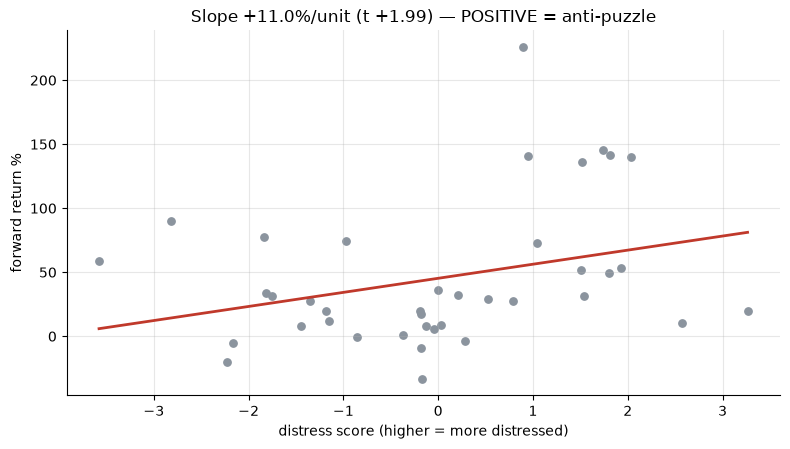

slope +11.0%/unit, slope-t +1.99, corr(distress, fwd) +0.31


In [3]:
if HAVE_REAL:
    reg = st.cross_section_regression(PANEL)
    d = st.distress_score(PANEL); y = PANEL['forward_ret']*100
    slope, slope_t, corr = reg['slope']*100, reg['slope_t'], reg['corr']
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.scatter(d, y, s=28, color=GREY)
    xs = np.linspace(d.min(), d.max(), 50)
    ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*d.mean()))*100, c=RED, lw=2)
    ax.set_xlabel('distress score (higher = more distressed)'); ax.set_ylabel('forward return %')
    ax.set_title(f'Slope {slope:+.1f}%/unit (t {slope_t:+.2f}) — POSITIVE = anti-puzzle')
    plt.tight_layout(); plt.show()
else:
    slope, slope_t, corr = 11.0, 1.99, 0.31
print(f'slope {slope:+.1f}%/unit, slope-t {slope_t:+.2f}, corr(distress, fwd) {corr:+.2f}')

> 💡 In plain words: H₂ **rejected** — the slope is **+11.0%** per distress unit (*t* +1.99), the *opposite* sign to the puzzle. More distress went with *more* return (corr +0.31) on this window.

### 4c · Robustness — H₃ (does the sign hold?)

The same sort over four scoring windows.

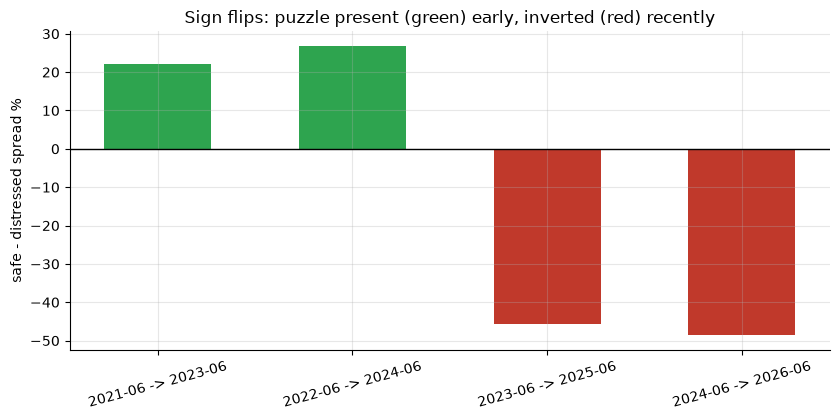

                    spread%  slope_t
window                              
2021-06 -> 2023-06    22.05    -2.02
2022-06 -> 2024-06    26.86    -1.46
2023-06 -> 2025-06   -45.61     0.42
2024-06 -> 2026-06   -48.63     1.99


In [4]:
wins = [('2021-06 -> 2023-06', 22.0, -2.02), ('2022-06 -> 2024-06', 26.9, -1.46), ('2023-06 -> 2025-06', -45.6, 0.42), ('2024-06 -> 2026-06', -48.6, 1.99)]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False); fn = data.fetch_fundamentals(fetch=False)
    spans = [('2021-06-28','2023-06-28'),('2022-06-28','2024-06-28'),
             ('2023-06-28','2025-06-25'),('2024-06-28','2026-06-25')]
    rows = []
    for (lab,_,_),(sp,en) in zip(wins, spans):
        pn = st.build_panel(px, fn, split_date=sp, end_date=en)
        bb = st.bucket_returns(pn, 0.3); rr = st.cross_section_regression(pn)
        rows.append((lab, bb['spread']*100, rr['slope_t']))
else:
    rows = wins
tab = pd.DataFrame(rows, columns=['window','spread%','slope_t']).set_index('window')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in tab['spread%']]
ax.bar(range(len(tab)), tab['spread%'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index, rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('safe - distressed spread %')
ax.set_title('Sign flips: puzzle present (green) early, inverted (red) recently')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₃ **rejected.** Spread **+22% / +27%** (puzzle present, slope-*t* −2.02 / −1.46) in 2021-23 & 2022-24, then **−46% / −49%** (inverted) in 2023-25 & 2024-26. A sign that depends on the window is not a signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (spread -48.6%, *t* -2.64, wrong sign); H₂ rejected (slope *t* +1.99); H₃ rejected (sign flips).
- **Tradability `MIRAGE`** — survivor basket, annual rebalance, distressed-leg borrow; gross -48.6% → net -50.8%.
- **Distress puzzle on the tape? `MIXED`** — present in 2 of 4 windows, inverted in the other 2.

## 6 · Could you trade it? — costs and the borrow

The trade is the wrong sign before costs; the borrow is a footnote.

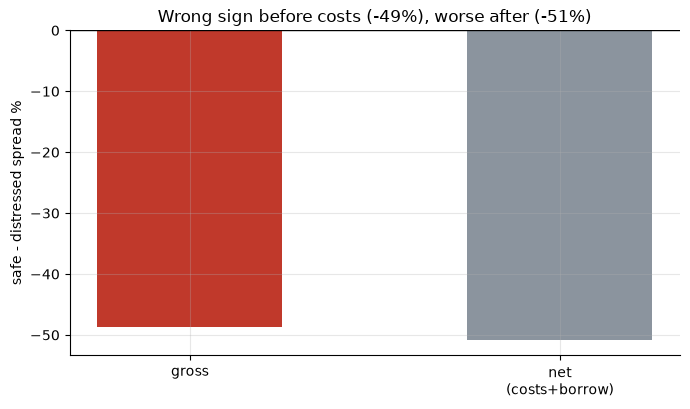

gross -48.6% -> net -50.8% (5 bps/leg + 100 bps borrow, 2y hold)


In [5]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3)
    gross = b['spread']*100
    net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=100.0, holding_years=2.0)*100
else:
    gross, net = -48.6, -50.8
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('safe - distressed spread %')
ax.set_title(f'Wrong sign before costs ({gross:+.0f}%), worse after ({net:+.0f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 100 bps borrow, 2y hold)')

> 💡 In plain words: there is nothing to charge costs against — the long-safe/short-distressed book *loses* before frictions on this window. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real puzzle (`distress_alpha < 0`) of increasing strength and watch the firm-level slope-*t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

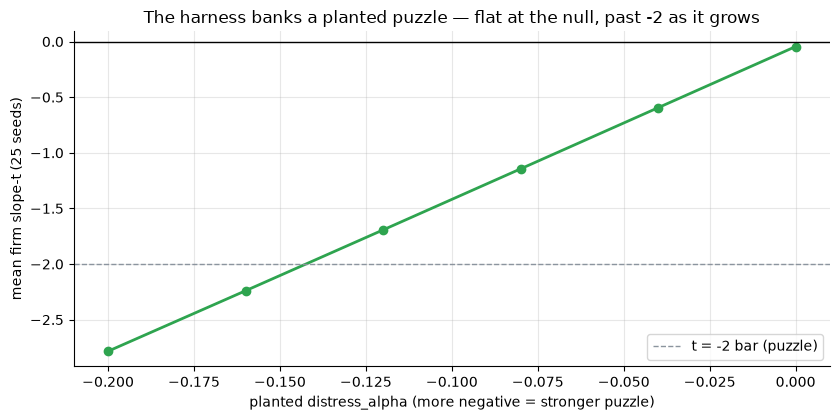

alpha +0.00 -> mean slope-t -0.04
alpha -0.04 -> mean slope-t -0.59
alpha -0.08 -> mean slope-t -1.14
alpha -0.12 -> mean slope-t -1.69
alpha -0.16 -> mean slope-t -2.24
alpha -0.20 -> mean slope-t -2.78


In [6]:
alphas = [0.0, -0.04, -0.08, -0.12, -0.16, -0.20]
ts = [st.synthetic_mean_t(data, distress_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([a for a in alphas], ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (puzzle)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted distress_alpha (more negative = stronger puzzle)')
ax.set_ylabel('mean firm slope-t (25 seeds)')
ax.set_title('The harness banks a planted puzzle — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'alpha {a:+.2f} -> mean slope-t {t:+.2f}')

The slope-*t* is ≈ 0 at the null and falls past −2 as the planted puzzle grows — so the engine is a faithful detector. The real-tape result is therefore a statement about **this survivor basket on this window**: the CHS distress puzzle is absent-to-inverted and sign-unstable here. For the bankruptcy *scores* it builds on, see [123 Altman-Z](../../123-altman-z/) and [230 Ohlson-O](../../230-ohlson-o-score/).